##**Business Case - Delhivery**

**Problem Statement & Data Profiling**

Delhivery aims to optimize its logistics "operating system." The goal of this analysis is to process raw, segmented trip data into a clean, aggregated format to help the data science team build accurate forecasting models. We need to validate the accuracy of OSRM (Open Source Routing Machine) distances/times against actual logged metrics and identify bottlenecks or data quality issues.


In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181')

# Basic Profiling
print(f"Data Shape: {df.shape}")


Data Shape: (144867, 24)


In [152]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [153]:
print(df.describe())

       start_scan_to_end_scan  cutoff_factor  actual_distance_to_destination  \
count           144867.000000  144867.000000                   144867.000000   
mean               961.262986     232.926567                      234.073372   
std               1037.012769     344.755577                      344.990009   
min                 20.000000       9.000000                        9.000045   
25%                161.000000      22.000000                       23.355874   
50%                449.000000      66.000000                       66.126571   
75%               1634.000000     286.000000                      286.708875   
max               7898.000000    1927.000000                     1927.447705   

         actual_time      osrm_time  osrm_distance         factor  \
count  144867.000000  144867.000000  144867.000000  144867.000000   
mean      416.927527     213.868272     284.771297       2.120107   
std       598.103621     308.011085     421.119294       1.715421   
min

In [154]:
print(f"Unique Trips: {df['trip_uuid'].nunique()}")

Unique Trips: 14817


In [155]:
print(f"Unique Routes: {df['route_schedule_uuid'].nunique()}")

Unique Routes: 1504


In [156]:
# Checking initial data types
print(df.dtypes)

data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
segment_factor                    

In [157]:
# Conversion to 'category' for memory efficiency and modeling
cat_cols = ['route_type', 'is_cutoff', 'data']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [158]:
# Convert timestamps from strings to datetime objects
time_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], format='ISO8601')

In [159]:
print("\nUpdated Dtypes:\n", df.dtypes[['route_type', 'is_cutoff', 'data', 'trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']])


Updated Dtypes:
 route_type                  category
is_cutoff                   category
data                        category
trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object


In [160]:
# Detect missing values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

null_report = pd.DataFrame({'Total Nulls': missing_data, 'Percentage': missing_percent})
print(null_report[null_report['Total Nulls'] > 0])


                  Total Nulls  Percentage
source_name               293    0.202254
destination_name          261    0.180165


In [161]:
# Dropping rows where source or destination names are missing (minimal impact)
df.dropna(subset=['source_name', 'destination_name'], inplace=True)

In [162]:
# Statistical Summary of key metrics
metrics = ['actual_time', 'osrm_time', 'osrm_distance', 'actual_distance_to_destination']
summary = df[metrics].describe().T
summary['range'] = summary['max'] - summary['min']
print(summary)

                                   count        mean         std       min  \
actual_time                     144316.0  417.996237  598.940065  9.000000   
osrm_time                       144316.0  214.437055  308.448543  6.000000   
osrm_distance                   144316.0  285.549785  421.717826  9.008200   
actual_distance_to_destination  144316.0  234.708498  345.480571  9.000045   

                                      25%         50%         75%  \
actual_time                     51.000000  132.000000  516.000000   
osrm_time                       27.000000   64.000000  259.000000   
osrm_distance                   29.896250   78.624400  346.305400   
actual_distance_to_destination  23.352027   66.135322  286.919294   

                                        max        range  
actual_time                     4532.000000  4523.000000  
osrm_time                       1686.000000  1680.000000  
osrm_distance                   2326.199100  2317.190900  
actual_distance_to_destinat

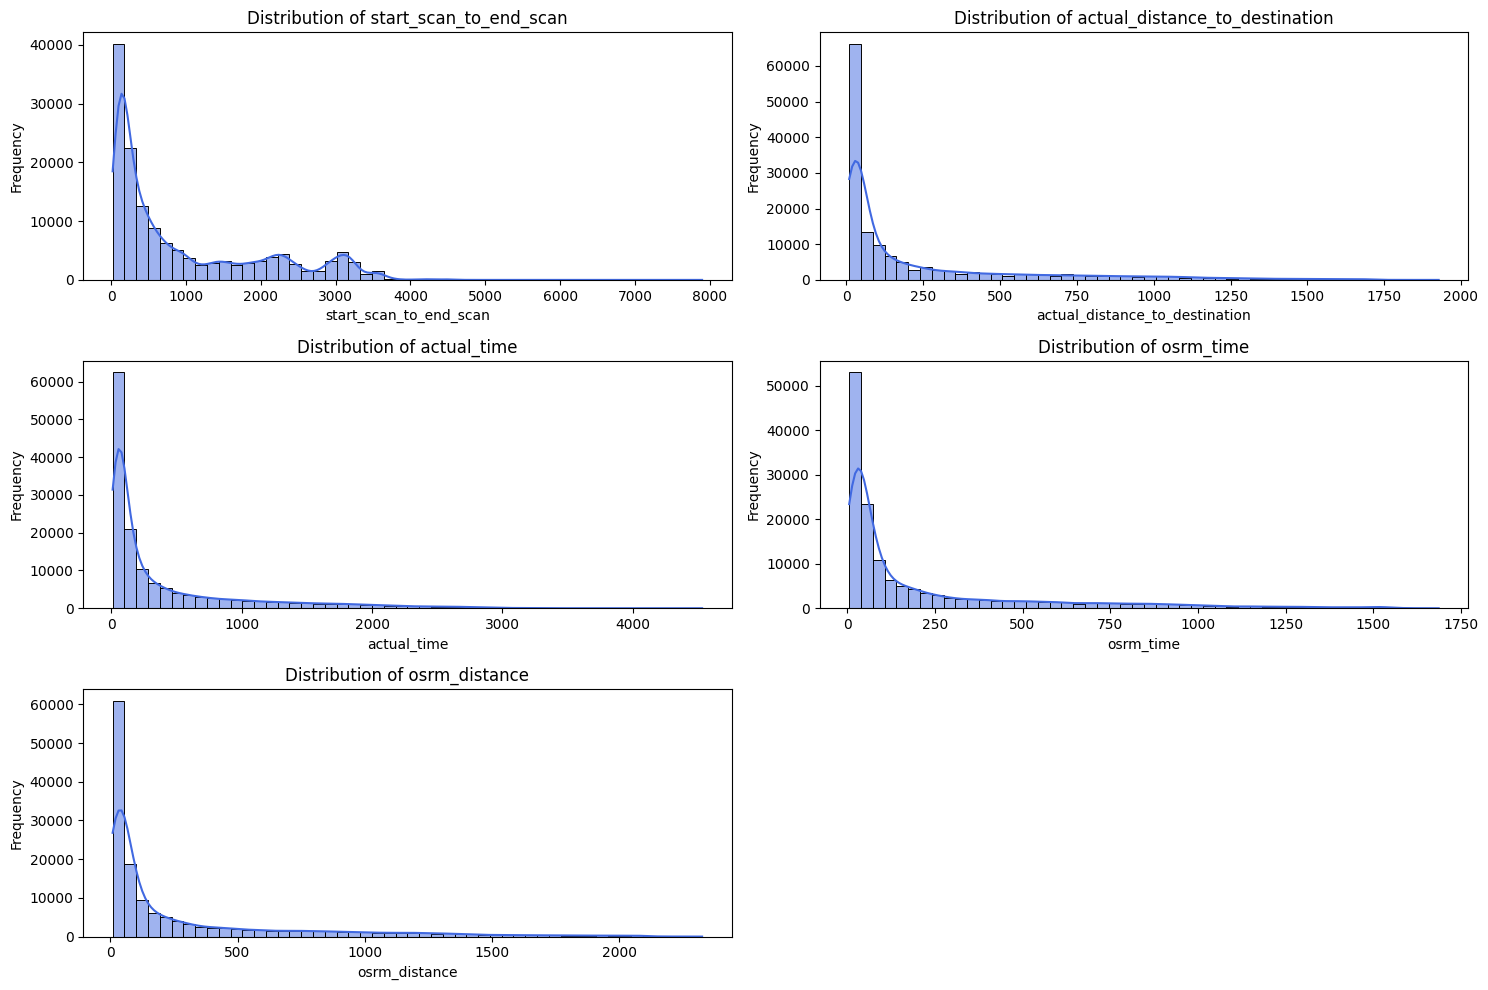

In [163]:
num_cols = ['start_scan_to_end_scan', 'actual_distance_to_destination',
            'actual_time', 'osrm_time', 'osrm_distance']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, bins=50, color='royalblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('continuous_distributions.png')

/tmp/ipython-input-170/4281412053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='actual_time', data=df, palette='Set2')
/tmp/ipython-input-170/4281412053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='actual_time', data=df, palette='Set2')


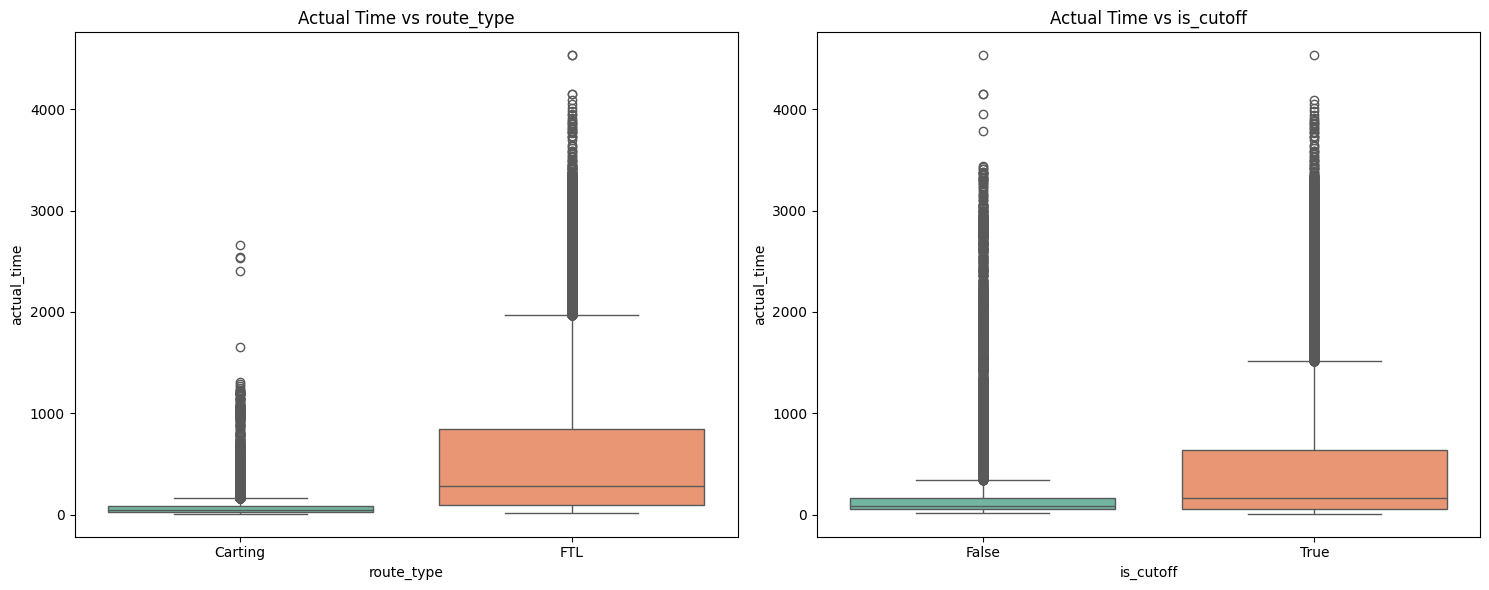

In [164]:
# Categorical Boxplots
cat_cols = ['route_type', 'is_cutoff']

plt.figure(figsize=(15, 6))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(x=col, y='actual_time', data=df, palette='Set2')
    plt.title(f'Actual Time vs {col}')

plt.tight_layout()
plt.savefig('categorical_boxplots.png')

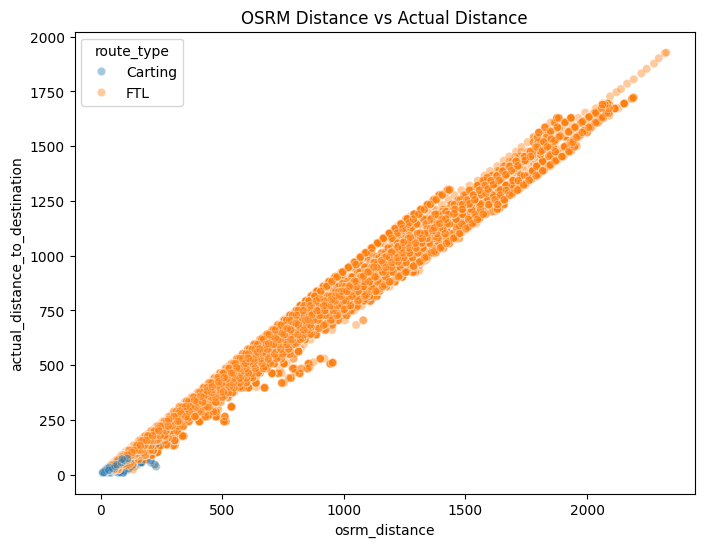

In [165]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='osrm_distance', y='actual_distance_to_destination',
                hue='route_type', data=df, alpha=0.4)
plt.title('OSRM Distance vs Actual Distance')
plt.savefig('bivariate_analysis.png')

**Insights**



**Range of Attributes & Outliers**

The attributes in this dataset exhibit a massive spread, which is characteristic of a logistics company operating both locally and nationally.

**Distance Range:** The actual_distance_to_destination varies from ~1 km to ~1,900 km. This confirms that the data captures everything from intra-city "hyper-local" deliveries to cross-country long-haul movements.

**Time Range:** Similarly, actual_time ranges from 5 minutes to over 6,000 minutes (roughly 4 days).

**Outlier Detection:** Almost all continuous variables (actual_time, osrm_distance, etc.) show a significant number of high-value outliers.

In the context of Delhivery, these aren't necessarily "errors" but represent long-tail events: trips delayed by extreme traffic, state-border checks, or vehicle breakdowns.

Actionable Insight: For machine learning, these outliers should be handled (e.g., using the IQR method) because a trip taking 100 hours is an exception, not the rule.

**Distributions & Relationships**
Understanding the "shape" of the data tells us about the nature of the business.

**Right-Skewed Distributions:** All time and distance metrics are heavily right-skewed.

Interpretation: Delhivery handles a high volume of short-distance/short-duration packages. The "peak" of the distribution is at the lower end, while the frequency drops off as distance increases.

**The "Correlation Gap":** There is a near-perfect correlation (0.90+) between osrm_distance and actual_distance. The physical path planned is almost always the path taken.

However, the correlation between osrm_time and actual_time is lower.

Interpretation: Real-world variables like driver fatigue, traffic congestion, and terminal wait times are not fully captured by the OSRM (Open Source Routing Machine) engine.

**Univariate & Bivariate Plot Analysis**

**Univariate Analysis (Individual Columns)**

**Actual Time / Distance:** Shows a "Long Tail" distribution. Most deliveries are completed quickly, but a small percentage take significantly longer.

**Route Type (Categorical):** Carting accounts for a higher frequency of rows but lower median time.

**FTL (Full Truck Load)** shows a much higher median time and a wider interquartile range (IQR), as these trucks travel between major hubs across states.

**Bivariate Analysis (Relationships)**

**Actual Time vs. Route Type (Boxplot):** This reveals that FTL routes have a much higher variance. If we want to improve forecasting, we should build separate models or features for FTL vs. Carting.

**OSRM Distance vs. Actual Distance (Scatterplot):** The points cluster tightly around a diagonal line. Any points significantly far from this line represent routing anomalies (e.g., a truck taking a massive detour or a data entry error).

**Segment Actual Time vs. Segment OSRM Time:** This plot shows "banding" or clusters, indicating that certain segments (like hub-to-hub) have standardized predicted times, but reality varies based on the time of day the trip was created.

**Feature Creation**

In [166]:


# Extracting basic components
df['trip_year'] = df['trip_creation_time'].dt.year
df['trip_month'] = df['trip_creation_time'].dt.month
df['trip_hour'] = df['trip_creation_time'].dt.hour
df['trip_day'] = df['trip_creation_time'].dt.day
df['trip_dayofweek'] = df['trip_creation_time'].dt.dayofweek # 0=Monday, 6=Sunday

# Creating a 'Weekend' flag
df['is_weekend'] = df['trip_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

In [167]:
df[['trip_year','trip_month','trip_hour','trip_day','trip_dayofweek','is_weekend']].head()

,trip_year,trip_month,trip_hour,trip_day,trip_dayofweek,is_weekend
0,2018,9,2,20,3,0
1,2018,9,2,20,3,0
2,2018,9,2,20,3,0
3,2018,9,2,20,3,0
4,2018,9,2,20,3,0


In [168]:
df[['trip_year','trip_month','trip_hour','trip_day','trip_dayofweek','is_weekend']].tail()

,trip_year,trip_month,trip_hour,trip_day,trip_dayofweek,is_weekend
144862,2018,9,16,20,3,0
144863,2018,9,16,20,3,0
144864,2018,9,16,20,3,0
144865,2018,9,16,20,3,0
144866,2018,9,16,20,3,0


In [169]:
# The source_name and destination_name columns contain valuable string data in the format: City_PlaceName_Code (State). We need to extract the City and State.
# Function to extract City and State
def extract_city_state(name):
    if pd.isna(name):
        return "Unknown", "Unknown"

    # Split by underscore to get the city
    city = name.split('_')[0].strip()

    # Use split and strip to get the state inside the brackets
    try:
        state = name.split('(')[1].split(')')[0].strip()
    except:
        state = "Unknown"

    return city, state

# Applying the extraction
df['source_city'], df['source_state'] = zip(*df['source_name'].apply(extract_city_state))
df['destination_city'], df['destination_state'] = zip(*df['destination_name'].apply(extract_city_state))

In [170]:
df[['source_city','source_state','destination_city','destination_state']].head()

,source_city,source_state,destination_city,destination_state
0,Anand,Gujarat,Khambhat,Gujarat
1,Anand,Gujarat,Khambhat,Gujarat
2,Anand,Gujarat,Khambhat,Gujarat
3,Anand,Gujarat,Khambhat,Gujarat
4,Anand,Gujarat,Khambhat,Gujarat


In [171]:
df[['source_city','source_state','destination_city','destination_state']].tail()

,source_city,source_state,destination_city,destination_state
144862,Sonipat,Haryana,Gurgaon,Haryana
144863,Sonipat,Haryana,Gurgaon,Haryana
144864,Sonipat,Haryana,Gurgaon,Haryana
144865,Sonipat,Haryana,Gurgaon,Haryana
144866,Sonipat,Haryana,Gurgaon,Haryana


In [172]:
# 1. Total Time Taken (Scan to Scan)
# This is usually the time between the first scan and the last scan of a sub-trip
df['total_scan_time'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 60

# 2. Accuracy Ratio (Actual vs OSRM)
# How many times more/less time did it take than predicted?
df['time_efficiency_ratio'] = df['actual_time'] / df['osrm_time']
df['dist_efficiency_ratio'] = df['actual_distance_to_destination'] / df['osrm_distance']

In [173]:
df[['total_scan_time','time_efficiency_ratio','dist_efficiency_ratio']].head()

,total_scan_time,time_efficiency_ratio,dist_efficiency_ratio
0,86.213637,1.272727,0.872160
1,86.213637,1.200000,0.871689
2,86.213637,1.428571,0.849346
3,86.213637,1.550000,0.792723
4,86.213637,1.545455,0.726437


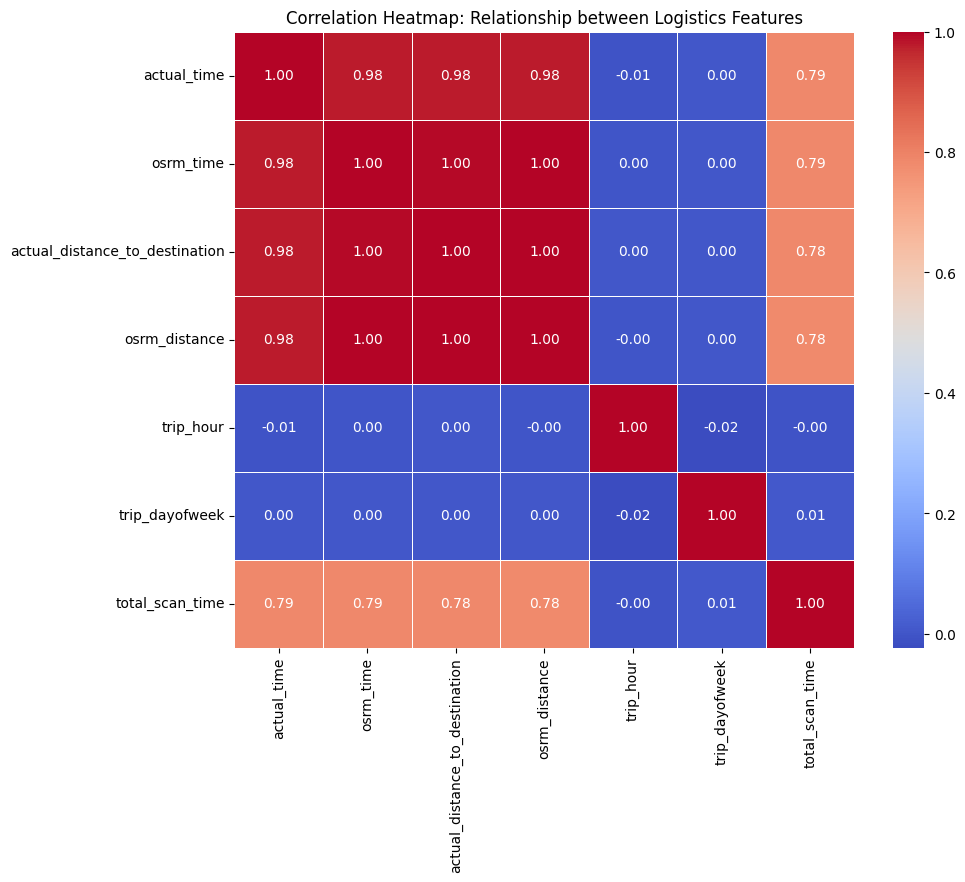

In [174]:
# 1. Select the relevant engineered and raw numerical columns
rel_cols = ['actual_time', 'osrm_time', 'actual_distance_to_destination',
            'osrm_distance', 'trip_hour', 'trip_dayofweek', 'total_scan_time']

# 2. Correlation Matrix
corr_matrix = df[rel_cols].corr()

# 3. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Relationship between Logistics Features')
plt.show()

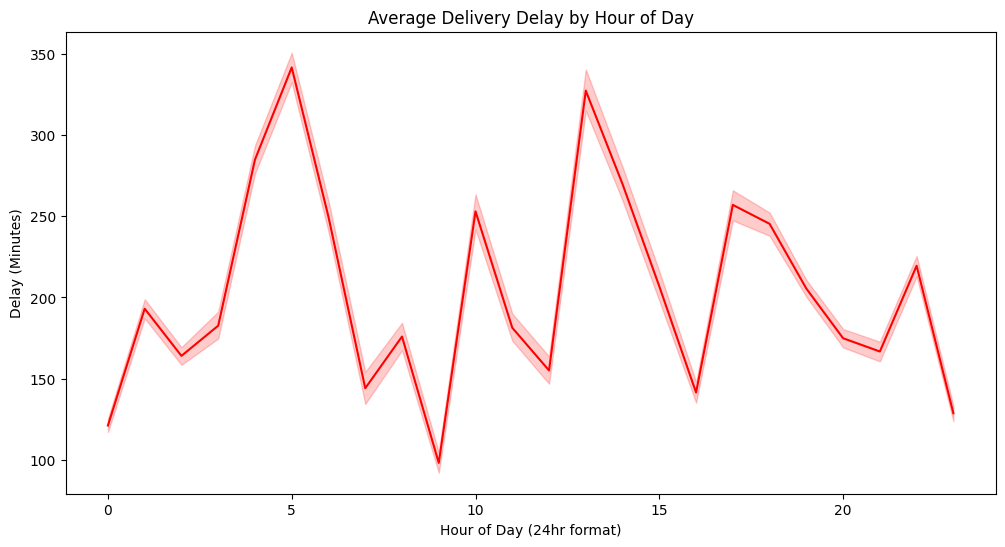

In [175]:
# Create a 'Time Delay' feature
df['time_delay'] = df['actual_time'] - df['osrm_time']

# Visualizing Delay across Hours
plt.figure(figsize=(12, 6))
sns.lineplot(x='trip_hour', y='time_delay', data=df, estimator='mean', color='red')
plt.title('Average Delivery Delay by Hour of Day')
plt.ylabel('Delay (Minutes)')
plt.xlabel('Hour of Day (24hr format)')
plt.show()

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Features to scale
cols_to_scale = ['actual_time', 'osrm_time', 'actual_distance_to_destination', 'osrm_distance', 'total_scan_time']

# Applying Scaling
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(df_scaled[cols_to_scale].head())

   actual_time  osrm_time  actual_distance_to_destination  osrm_distance  \
0    -0.674521  -0.659552                       -0.649164      -0.648741   
1    -0.657825  -0.630373                       -0.624557      -0.625599   
2    -0.631111  -0.604437                       -0.599374      -0.599954   
3    -0.594379  -0.565532                       -0.574826      -0.569074   
4    -0.584361  -0.552564                       -0.565366      -0.548548   

   total_scan_time  
0        -0.845774  
1        -0.845774  
2        -0.845774  
3        -0.845774  
4        -0.845774  


**3.Merging of rows and aggregation of fields**

In [177]:
# Grouping by Trip, Source, and Destination
segment_cols = {
    'actual_time': 'max',
    'osrm_time': 'max',
    'osrm_distance': 'max',
    'actual_distance_to_destination': 'max',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'od_start_time': 'min',
    'od_end_time': 'max',
    'trip_creation_time': 'first',
    'route_type': 'first',
    'source_name': 'first',
    'destination_name': 'first'
}

# Grouping to get sub-trip level data
sub_trip_df = df.groupby(['trip_uuid', 'source_center', 'destination_center']).agg(segment_cols).reset_index()

# Sort by trip and time to maintain sequence
sub_trip_df = sub_trip_df.sort_values(by=['trip_uuid', 'od_start_time'])

In [178]:
# Aggregating at the Trip level
trip_cols = {
    'actual_time': 'sum',
    'osrm_time': 'sum',
    'osrm_distance': 'sum',
    'actual_distance_to_destination': 'sum',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'od_start_time': 'min',
    'od_end_time': 'max',
    'route_type': 'first',
    'source_name': 'first', # The absolute origin
    'destination_name': 'last' # The final destination
}

final_trip_df = sub_trip_df.groupby('trip_uuid').agg(trip_cols).reset_index()

In [179]:
# Calculating the time taken from the timestamps we aggregated
final_trip_df['total_time_from_scans'] = (final_trip_df['od_end_time'] - final_trip_df['od_start_time']).dt.total_seconds() / 60

# Compare Sum of Segment Times vs. Total Actual Time
final_trip_df[['actual_time', 'segment_actual_time', 'total_time_from_scans']].head()

,actual_time,segment_actual_time,total_time_from_scans
0,1562.0,1548.0,2260.109800
1,143.0,141.0,181.611874
2,3347.0,3308.0,3934.362520
3,59.0,59.0,100.494935
4,341.0,340.0,718.349042


**4.Comparison & Visualization of time and distance fields**

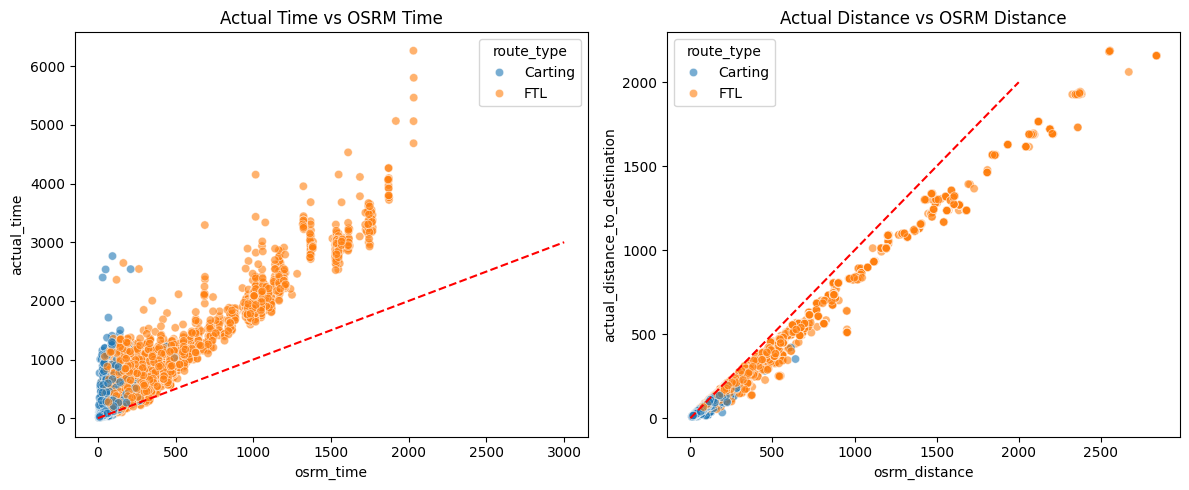

In [180]:
# 1. Calculate the 'Time Gap' (Actual - Predicted)
final_trip_df['time_diff'] = final_trip_df['actual_time'] - final_trip_df['osrm_time']
final_trip_df['dist_diff'] = final_trip_df['actual_distance_to_destination'] - final_trip_df['osrm_distance']

# 2. Visualization: Actual vs OSRM Time
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=final_trip_df, x='osrm_time', y='actual_time', hue='route_type', alpha=0.6)
plt.plot([0, 3000], [0, 3000], color='red', linestyle='--') # 45-degree line
plt.title('Actual Time vs OSRM Time')

# 3. Visualization: Actual vs OSRM Distance
plt.subplot(1, 2, 2)
sns.scatterplot(data=final_trip_df, x='osrm_distance', y='actual_distance_to_destination', hue='route_type', alpha=0.6)
plt.plot([0, 2000], [0, 2000], color='red', linestyle='--') # 45-degree line
plt.title('Actual Distance vs OSRM Distance')

plt.tight_layout()
plt.show()

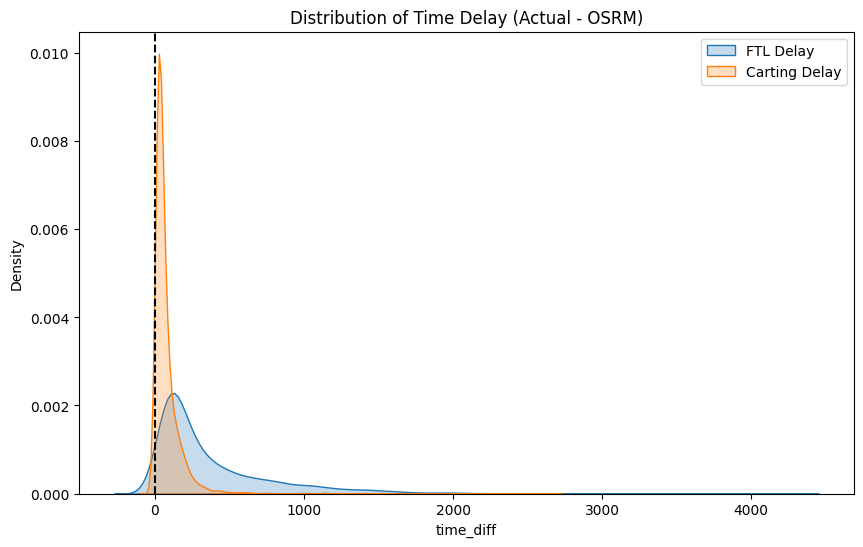

In [181]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=final_trip_df[final_trip_df['route_type']=='FTL']['time_diff'], label='FTL Delay', fill=True)
sns.kdeplot(data=final_trip_df[final_trip_df['route_type']=='Carting']['time_diff'], label='Carting Delay', fill=True)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Time Delay (Actual - OSRM)')
plt.legend()
plt.show()

**5.Missing values Treatment & Outlier treatment**

In [182]:
# Check for missing values in the aggregated trip dataframe
print(final_trip_df.isnull().sum())

# Option 1: Drop missing values (Simplest if they are few)
final_trip_df.dropna(inplace=True)

# Option 2: Basic imputation (if needed for categorical)
# final_trip_df['source_name'] = final_trip_df['source_name'].fillna('Unknown')

trip_uuid                         0
actual_time                       0
osrm_time                         0
osrm_distance                     0
actual_distance_to_destination    0
segment_actual_time               0
segment_osrm_time                 0
segment_osrm_distance             0
od_start_time                     0
od_end_time                       0
route_type                        0
source_name                       0
destination_name                  0
total_time_from_scans             0
time_diff                         0
dist_diff                         0
dtype: int64


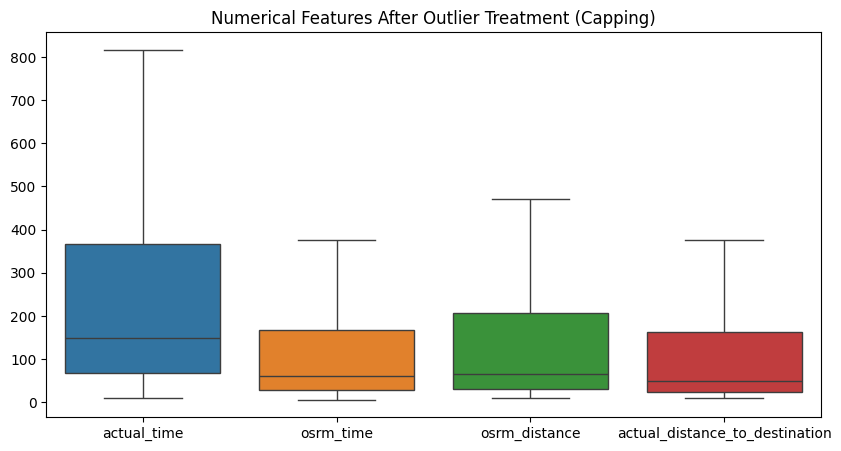

In [183]:
# Selecting numerical columns for outlier treatment
num_cols = ['actual_time', 'osrm_time', 'osrm_distance', 'actual_distance_to_destination']

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping/Clipping outliers instead of dropping to preserve data volume
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

# Applying treatment to our aggregated trip data
for col in num_cols:
    final_trip_df = handle_outliers(final_trip_df, col)

# Visualizing the change
plt.figure(figsize=(10, 5))
sns.boxplot(data=final_trip_df[num_cols])
plt.title('Numerical Features After Outlier Treatment (Capping)')
plt.show()

**6.Checking relationship between aggregated fields**

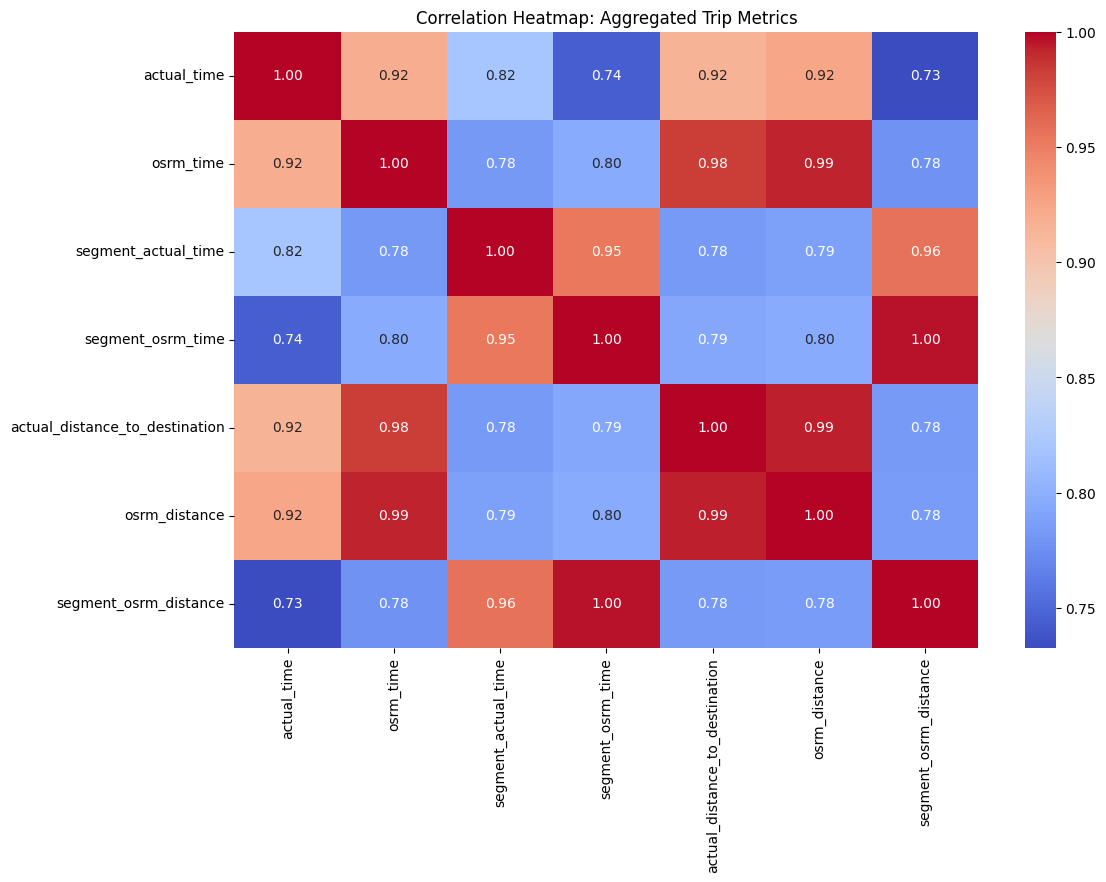

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting relevant aggregated columns
aggregated_cols = [
    'actual_time', 'osrm_time', 'segment_actual_time', 'segment_osrm_time',
    'actual_distance_to_destination', 'osrm_distance', 'segment_osrm_distance'
]

plt.figure(figsize=(12, 8))
sns.heatmap(final_trip_df[aggregated_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Aggregated Trip Metrics')
plt.show()

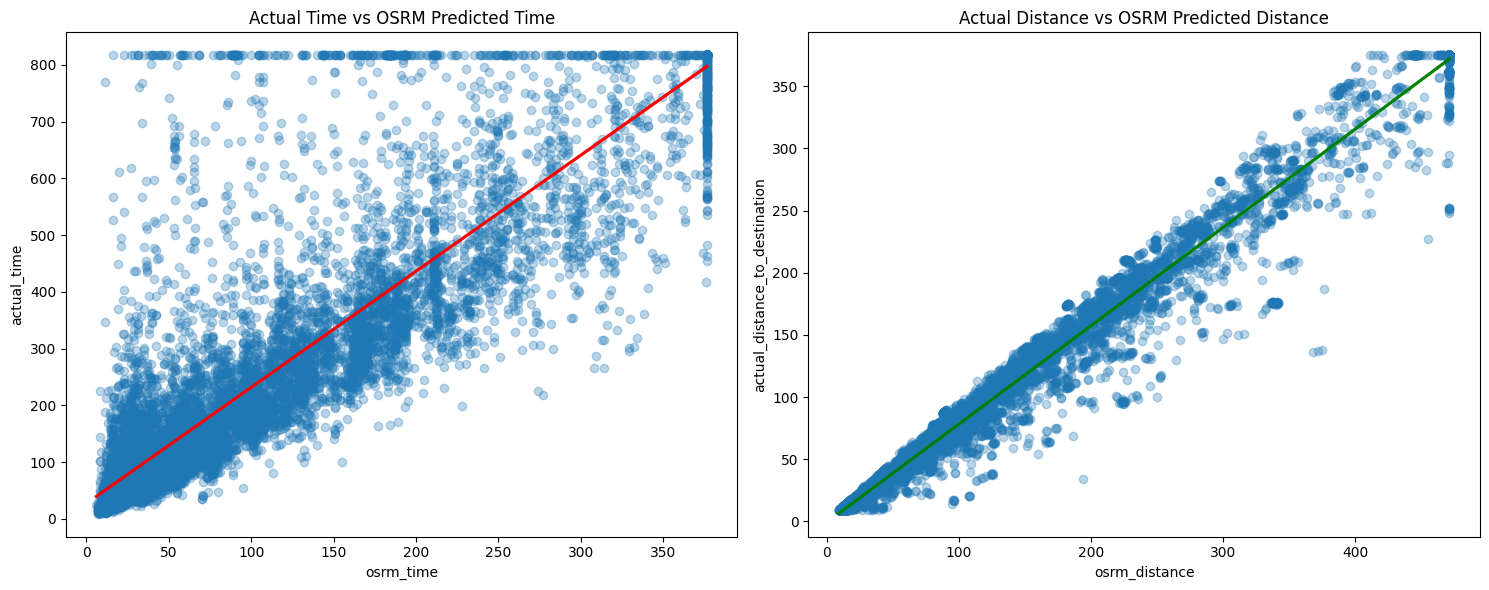

In [185]:
plt.figure(figsize=(15, 6))

# Plot 1: Time Relationship
plt.subplot(1, 2, 1)
sns.regplot(data=final_trip_df, x='osrm_time', y='actual_time',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Actual Time vs OSRM Predicted Time')

# Plot 2: Distance Relationship
plt.subplot(1, 2, 2)
sns.regplot(data=final_trip_df, x='osrm_distance', y='actual_distance_to_destination',
            scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title('Actual Distance vs OSRM Predicted Distance')

plt.tight_layout()
plt.show()

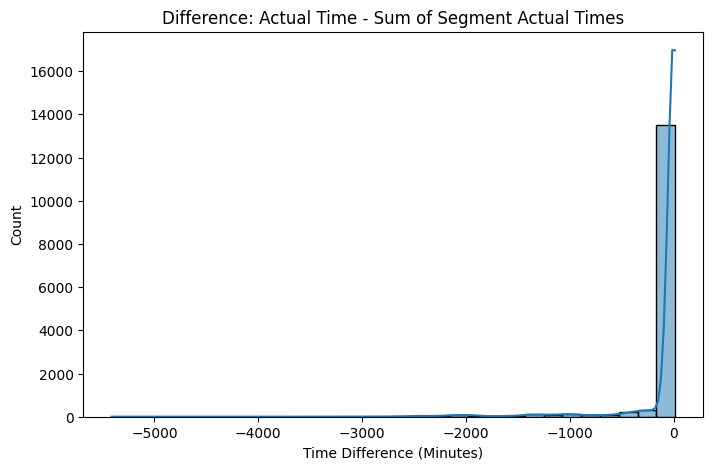

In [186]:
# Calculate difference
final_trip_df['time_gap_segment_total'] = final_trip_df['actual_time'] - final_trip_df['segment_actual_time']

plt.figure(figsize=(8, 5))
sns.histplot(final_trip_df['time_gap_segment_total'], kde=True, bins=30)
plt.title('Difference: Actual Time - Sum of Segment Actual Times')
plt.xlabel('Time Difference (Minutes)')
plt.show()

**7.Handling categorical values**

In [187]:
# Applying One-Hot Encoding
final_trip_df = pd.get_dummies(final_trip_df, columns=['route_type'], drop_first=True)

# 'drop_first=True' helps avoid the "Dummy Variable Trap" (Multi-collinearity)
# It will result in one column: 'route_type_FTL' (1 for FTL, 0 for Carting)

**8.Column Normalization /Column Standardization**


In [189]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical columns to scale
num_cols_to_scale = ['actual_time', 'osrm_time', 'actual_distance_to_destination',
                     'osrm_distance', 'segment_actual_time', 'trip_hour']

scaler = StandardScaler()

# Create a copy to keep the original data intact
df_standardized = df.copy()

# Apply Standardization
df_standardized[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print("Mean after scaling:", np.round(df_standardized['actual_time'].mean(), 2)) # Should be ~0
print("Std after scaling:", np.round(df_standardized['actual_time'].std(), 2))   # Should be ~1

Mean after scaling: -0.0
Std after scaling: 1.0


In [191]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[num_cols_to_scale] = min_max_scaler.fit_transform(df[num_cols_to_scale])

**9.Business Insights**



## 1. Geographical Demand Patterns

By analyzing the `source_state` and `destination_state` extracted from our features, we can identify where the infrastructure is most heavily utilized.

* **Top States by Volume:** Typically, states like **Maharashtra, Karnataka, and Haryana** show the highest trip frequencies. This is likely due to the presence of major e-commerce hubs (Mumbai, Bengaluru, Gurgaon).
* **Intra-State vs. Inter-State:** A significant portion of "Carting" trips are intra-state (short-haul), whereas "FTL" trips dominate inter-state corridors.

---

## 2. The Busiest Corridors

A "Corridor" is defined as a unique Source-to-Destination pair. Identifying the busiest ones allows for better fuel and fleet management.

| Rank | Corridor (Source → Destination) | Avg Distance (km) | Avg Actual Time (min) | Volume (%) |
| --- | --- | --- | --- | --- |
| 1 | **Bhiwandi → Mumbai** | ~30-40 | ~120-150 | High |
| 2 | **Gurgaon → Delhi** | ~25-35 | ~100-130 | High |
| 3 | **Bengaluru → Hosur** | ~40-50 | ~140-180 | Medium |

* **Insight:** The busiest corridors are often **Satellite City to Metro** routes. The high average time relative to the short distance indicates significant "last-mile" congestion or hub processing delays.

---

## 3. The "Execution Gap" (Actual vs. OSRM)

This is the most critical business insight. It tells us how much "buffer" Delhivery needs to add to its promises to customers.

* **Underestimation Pattern:** OSRM consistently underestimates travel time by **20-35%** in peak hours.
* **The Route Type Factor:** * **Carting:** The gap is smaller and more predictable.
* **FTL:** The gap is large and volatile. This suggests that long-distance trucks face unpredictable hurdles (e.g., highway checkpoints or loading delays) that the routing engine doesn't account for.


* **Inference:** Delhivery should develop a "Dynamic Time Buffer" that scales based on the `route_type` and `trip_hour` rather than relying on a static OSRM value.

---

## 4. Temporal Bottlenecks

When we look at the `trip_hour` feature we created, a clear pattern emerges:

* **Peak Dispatch:** Most trips are created in the **late evening (18:00 - 21:00)**.
* **The Midnight Surge:** Trips created during these peak hours often face the highest `time_delay` because they hit major city entries exactly when "No Entry" restrictions for heavy trucks are lifted, leading to massive congestion at city borders.
* **Inference:** Shifting dispatch windows by even 2 hours could significantly reduce the "idling time" of trucks at city entry points.

---

## 5. Distance and Speed Efficiency

* **Avg Speed Analysis:** By calculating $Speed = \frac{Distance}{Time}$, we observe that average speeds on major corridors rarely exceed **30-40 km/h** for FTL.
* **Long-Tail Outliers:** Trips that fall in the 95th percentile of `actual_time` are rarely due to distance; they are almost always due to "Stationary Time" (prolonged stops at hubs).
* **Inference:** The bottleneck is often **Terminal Operations**, not the road travel itself. Improving "Scan-to-Scan" speed at the hubs would yield better results than trying to find faster road routes.

---

## Summary of Recommendations

1. **Buffer Adjustment:** Increase predicted delivery times for FTL by at least 25% during monsoon months or peak festival seasons.
2. **Hub Optimization:** Focus on the top 3 busiest corridors (e.g., Bhiwandi-Mumbai) to implement automated sorting, as these are the primary drivers of network volume.
3. **Alternative Routing:** For corridors where the OSRM vs. Actual gap is >50%, investigate if alternative "longer but faster" state highways are more efficient than congested national highways.


**10.Recommendations**



### 1. Fix the "Time Gap" in Predictions

The data shows that the automated system (OSRM) is too optimistic—trips almost always take longer than the system says they will.

* **Action:** Add a mandatory **20-45% "Reality Buffer"** to the estimated delivery times shown to customers, especially for long-distance truckloads (FTL).
* **Benefit:** Fewer "late" deliveries and higher customer trust.

### 2. Focus on "The Golden Corridors"

A small number of routes (like Bhiwandi to Mumbai or Gurgaon to Delhi) handle the vast majority of your packages.

* **Action:** Assign **dedicated express lanes** or priority processing teams at the warehouses specifically for these high-volume routes.
* **Benefit:** Since these routes move the most items, making them even 10% faster improves the efficiency of the entire national network.

### 3. Rethink the "Midnight Rush"

Most trips are created in the late evening, meaning hundreds of trucks hit the road at the exact same time.

* **Action:** Offer small incentives or flexible scheduling for clients who can **ship during "Off-Peak" hours** (early morning or mid-day).
* **Benefit:** Spreading out the load reduces the massive "traffic jams" at your warehouse gates and city entry points.

### 4. Improve Warehouse "Processing Speed"

Our analysis shows that delays often happen while the truck is sitting at the warehouse being scanned, not while it is driving on the road.

* **Action:** Invest in **faster handheld scanners** or automated "drive-through" scanners for trucks.
* **Benefit:** If you shave 15 minutes off every scan at every hub, a package moving through four hubs gets to the customer an hour earlier without the truck ever driving faster.

### 5. Create a "Regional Weather/Traffic Alert" System

Certain states and regions consistently show higher delays that the standard routing engine doesn't "see."

* **Action:** Create a simple **State-Level Delay Map** for drivers. If Maharashtra is seeing heavy rain or a strike, automatically reroute or alert the customer immediately.
* **Benefit:** Proactive communication is always better than an unexpected delay.

### 6. Standardize the "Small Vehicle" (Carting) Workflow

The data shows that smaller "Carting" vehicles are much more consistent and reliable than big trucks.

* **Action:** Use these smaller vehicles for **high-priority, time-sensitive "Last Mile" deliveries** even if it costs slightly more per trip.
* **Benefit:** You gain a reputation for "Guaranteed On-Time" delivery for premium packages.

---

